# Experiment 6: Resize + Normalisasi + CLAHE HSV + Gamma Correction (balanced dataset)

Eksperimen ini berfokus pada alur preprocessing yang diusulkan:
1. **Resize** ke 256x256 piksel (otomatis saat pemuatan dataset).
2. **Normalisasi Min-Max** untuk meratakan kontras global citra ke rentang [0, 255].
3. **CLAHE pada HSV** (kontras lokal ditingkatkan pada S & V) untuk memperjelas batas awan.
4. **Gamma Correction (gamma=1.2)** untuk meningkatkan detail pada area midtone/shadows awan.
5. **RGB/Color-based Extraction & Texture Extraction** (HSV, NRBR, LBP, dan GLCM) untuk melatih model klasifikasi.

In [13]:
import sys
sys.path.append('..')  # supaya src/ bisa diimport dari notebooks/

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops
from src.loader import get_dataset_root, load_dataset
from src.image_processing import *

EXPERIMENT_NAME = "experiment6"


Kode tersebut berfungsi sebagai tahap inisialisasi dan persiapan lingkungan kerja sebelum proses pengolahan citra, ekstraksi fitur, pelatihan model, dan evaluasi dilakukan. Pada bagian ini, berbagai library yang dibutuhkan diimpor, seperti NumPy dan Pandas untuk pengolahan data, OpenCV dan scikit-image untuk pengolahan citra serta ekstraksi fitur tekstur GLCM, Matplotlib dan Seaborn untuk visualisasi, serta Scikit-learn untuk pembagian dataset, pelatihan model klasifikasi (Random Forest, SVM, dan KNN), dan evaluasi performa model. Selain itu, kode juga mengimpor fungsi-fungsi khusus dari folder src, seperti pemuatan dataset dan preprocessing citra, sehingga seluruh fungsi yang telah dibuat dapat digunakan pada notebook. Variabel EXPERIMENT_NAME = "experiment6" digunakan untuk memberikan identitas pada eksperimen yang sedang dijalankan agar hasil pengujian dapat dibedakan dari eksperimen lainnya. Dengan demikian, tujuan utama kode ini adalah menyiapkan seluruh komponen yang diperlukan untuk menjalankan eksperimen klasifikasi citra awan pada Experiment 6.

## Data Loading (Balanced to Max 1250 per Class)

Kode tersebut bertujuan untuk **memuat dataset citra awan yang akan digunakan dalam eksperimen klasifikasi**. Pertama, fungsi `get_dataset_root()` digunakan untuk memperoleh lokasi direktori utama dataset. Selanjutnya, fungsi `load_dataset()` digunakan untuk membaca seluruh gambar dari dataset dengan ukuran yang telah diseragamkan menjadi **256×256 piksel** (`target_size=(256, 256)`) dan dalam format **gambar berwarna** (`color=True`). Penggunaan gambar berwarna diperlukan karena pada eksperimen ini dilakukan ekstraksi fitur yang memanfaatkan informasi warna, seperti **HSV** dan **NRBR**. Fungsi tersebut menghasilkan tiga keluaran, yaitu `images` yang berisi data citra, `labels` yang berisi label kelas masing-masing citra, serta `filenames` yang berisi nama file gambar. Terakhir, perintah `print()` digunakan untuk menampilkan jumlah total gambar yang berhasil dimuat dan jumlah kelas yang terdapat dalam dataset sebagai bentuk verifikasi bahwa proses pemuatan data telah berhasil dilakukan.

In [14]:
DATASET_ROOT = get_dataset_root()
# Muat gambar warna (color=True) agar ekstraksi HSV dan NRBR bisa dilakukan
# Default max_per_class=1250 dan target_size=(256, 256) otomatis digunakan
images, labels, filenames = load_dataset(DATASET_ROOT, target_size=(256, 256), color=True)
print(f"Dataset loaded: {len(images)} gambar warna, {len(set(labels))} kelas")

Environment: Lokal
DATASET_ROOT dari .env: C:\Users\ADVAN\Downloads\train-20260615T123127Z-3-001\train


Dataset loaded: 6751 gambar, 7 kelas, ukuran=(256, 256)
Dataset loaded: 6751 gambar warna, 7 kelas


## Preprocessing Pipeline (Min-Max Normalization -> CLAHE HSV -> Gamma Correction)

In [15]:
# ================================================================
# EDIT BAGIAN INI untuk mengubah pipeline preprocessing
# Tambah, hapus, atau ganti fungsi sesuai experiment
# ================================================================

PIPELINE = [
    lambda img: normalize_minmax(img),
    lambda img: clahe_hsv(img, tile_size=8, clip_limit=2.0),
    lambda img: gamma_correction(img, gamma=1.2),
]

# ================================================================
# Jangan edit di bawah ini
# ================================================================

def apply_pipeline(image: np.ndarray, pipeline: list) -> np.ndarray:
    for fn in pipeline:
        image = fn(image)
    return image


Kode tersebut bertujuan untuk **menerapkan pipeline preprocessing pada seluruh citra dalam dataset sebelum dilakukan ekstraksi fitur dan proses klasifikasi**. Fungsi `process_one()` digunakan untuk menjalankan fungsi `apply_pipeline()` pada setiap gambar berdasarkan tahapan preprocessing yang telah ditentukan dalam variabel `PIPELINE`. Selanjutnya, program memeriksa apakah pemrosesan GPU sedang aktif melalui variabel `USING_GPU`. Jika GPU aktif, proses preprocessing dijalankan secara paralel menggunakan **ThreadPoolExecutor** dengan empat worker sehingga beberapa gambar dapat diproses secara bersamaan dan waktu komputasi menjadi lebih cepat. Sebaliknya, jika GPU tidak aktif, preprocessing dilakukan secara berurutan (sekuensial) menggunakan CPU. Library **tqdm** digunakan untuk menampilkan progress bar sehingga pengguna dapat memantau perkembangan proses preprocessing. Setelah seluruh gambar selesai diproses, hasilnya disimpan dalam variabel `images_preprocessed_color` dan kemudian dikonversi menjadi array NumPy agar lebih mudah digunakan pada tahap ekstraksi fitur dan pelatihan model selanjutnya.

In [16]:
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

def process_one(img):
    return apply_pipeline(img, PIPELINE)

print("Menjalankan Preprocessing Pipeline...")
if USING_GPU:
    print("Menggunakan ThreadPoolExecutor (GPU aktif)...")
    with ThreadPoolExecutor(max_workers=4) as executor:
        images_preprocessed_color = list(tqdm(
            executor.map(process_one, images),
            total=len(images),
            desc="Preprocessing"
        ))
else:
    print("Menggunakan Pemrosesan Sekuensial CPU...")
    images_preprocessed_color = [process_one(img) for img in tqdm(images, desc="Preprocessing")]
    
images_preprocessed_color = np.array(images_preprocessed_color)

Menjalankan Preprocessing Pipeline...
Menggunakan Pemrosesan Sekuensial CPU...


Preprocessing: 100%|██████████| 6751/6751 [04:40<00:00, 24.04it/s]


## Visualisasi Preprocessing Bertahap

Melihat efek dari setiap tahapan preprocessing secara bertahap.

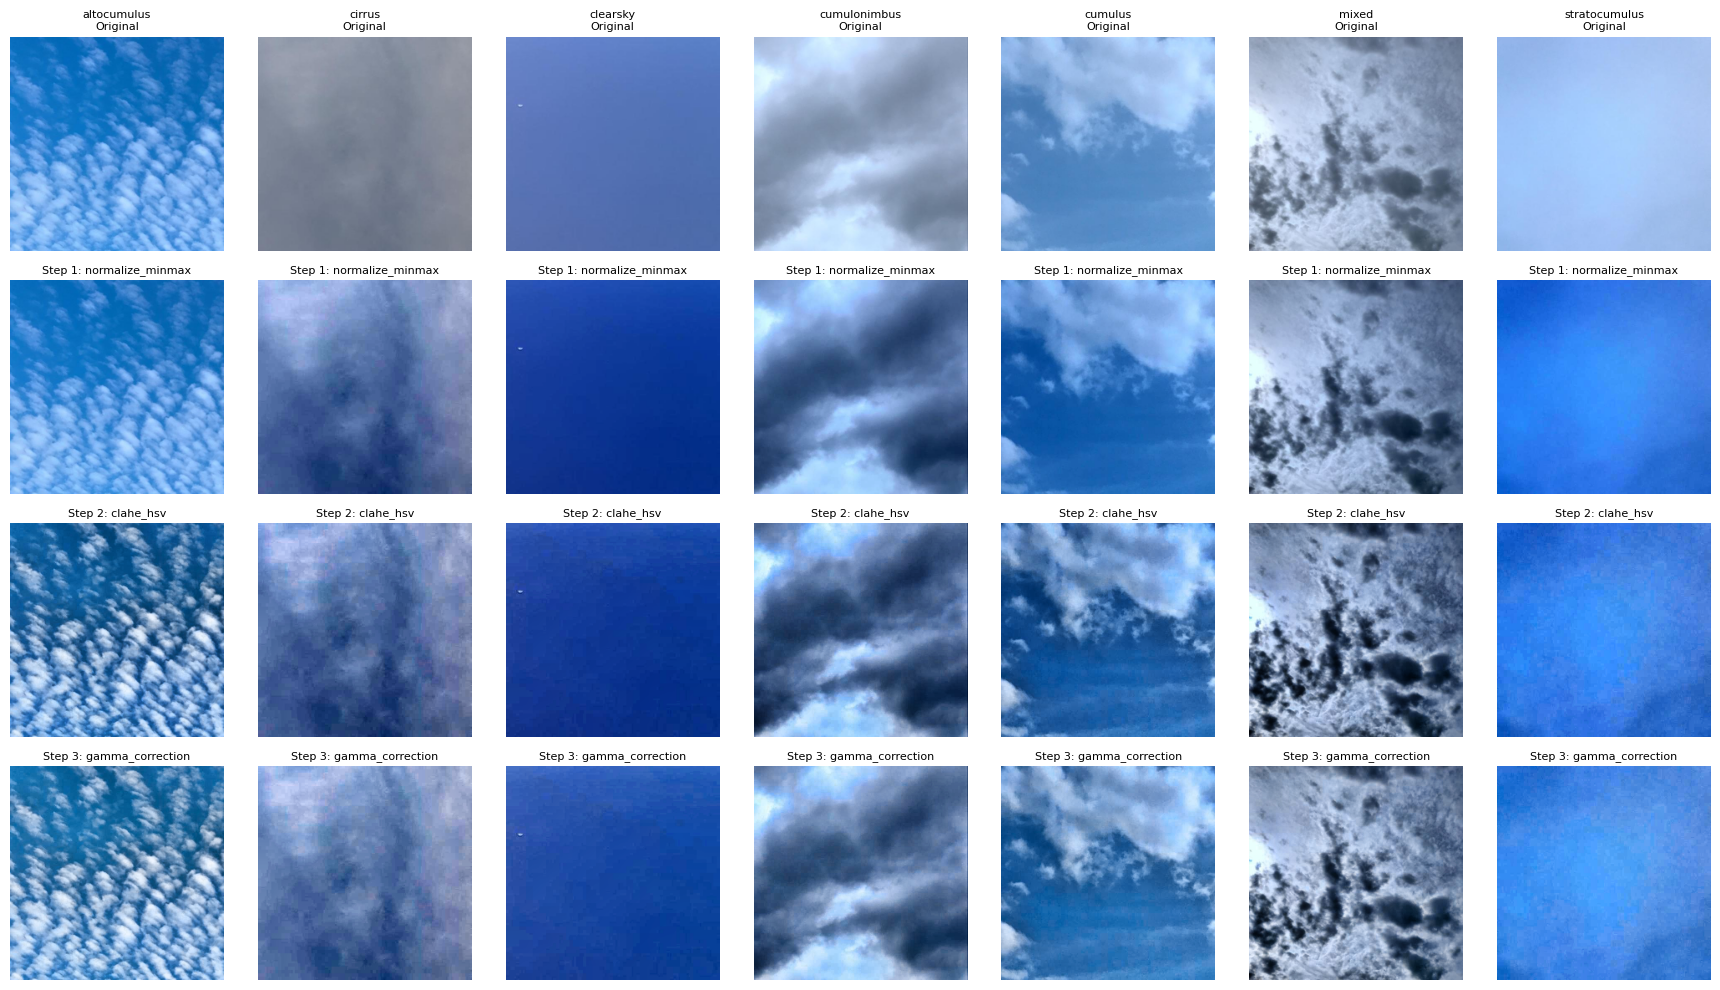

In [17]:
# Visualisasi Preprocessing Bertahap secara otomatis untuk semua tahapan
visualize_pipeline_steps(images, labels, PIPELINE)


In [18]:
# Konversi hasil preprocessing ke grayscale khusus untuk ekstraksi fitur GLCM & LBP
print("Mengonversi gambar preprocessed ke grayscale...")
images_preprocessed = np.array([
    cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in tqdm(images_preprocessed_color, desc="Converting to grayscale")
])

Mengonversi gambar preprocessed ke grayscale...


Converting to grayscale: 100%|██████████| 6751/6751 [00:00<00:00, 10780.52it/s]


## Feature Extraction - Color & Texture

Kita mengekstrak:
- **HSV Color Stats & Histograms**
- **NRBR Color Stats & Histograms**
- **LBP Texture Histograms**
- **GLCM Texture Features**

Kode tersebut bertujuan untuk **mengekstrak fitur warna dan tekstur dari citra yang telah melalui tahap preprocessing** sehingga dapat digunakan sebagai masukan bagi model klasifikasi. Pertama, dilakukan ekstraksi **fitur warna HSV (Hue, Saturation, Value)** menggunakan fungsi `extract_hsv_features()`. Proses ini menghasilkan berbagai informasi statistik seperti histogram, nilai rata-rata (mean), standar deviasi (std), skewness, dan kurtosis untuk setiap kanal H, S, dan V. Fitur-fitur tersebut digunakan untuk merepresentasikan karakteristik warna citra awan.

Selanjutnya, dilakukan ekstraksi **fitur NRBR (Normalized Red-Blue Ratio)** melalui fungsi `extract_nrbr_features()`. NRBR digunakan untuk mengukur hubungan antara kanal merah dan biru pada citra, yang dapat membantu membedakan karakteristik warna langit dan awan. Dari proses ini dihasilkan histogram serta fitur statistik seperti mean, standar deviasi, skewness, dan kurtosis.

Setelah itu, dilakukan ekstraksi **fitur tekstur menggunakan Local Binary Pattern (LBP)** melalui fungsi `extract_lbp_features()`. Metode LBP bekerja dengan membandingkan nilai piksel pusat dengan piksel-piksel di sekitarnya untuk membentuk pola tekstur lokal. Hasil ekstraksi berupa histogram LBP yang menggambarkan distribusi pola tekstur pada citra. Secara keseluruhan, tujuan kode ini adalah mengubah citra hasil preprocessing menjadi sekumpulan fitur numerik yang mampu merepresentasikan informasi warna dan tekstur awan sehingga dapat digunakan pada tahap pelatihan dan pengujian model klasifikasi.


In [19]:
# Ekstrasi Fitur Warna HSV
print("Mengekstrak fitur HSV...")
h_hists, s_hists, v_hists, \
h_means, h_stds, h_skews, h_kurts, \
s_means, s_stds, s_skews, s_kurts, \
v_means, v_stds, v_skews, v_kurts = extract_hsv_features(images_preprocessed_color)

# Ekstraksi Fitur Warna NRBR (Normalized Red-Blue Ratio)
print("Mengekstrak fitur NRBR...")
nrbr_hists, nrbr_means, nrbr_stds, nrbr_skews, nrbr_kurts = extract_nrbr_features(images_preprocessed_color)

# Ekstraksi Fitur Tekstur LBP (Local Binary Pattern)
print("Mengekstrak fitur LBP...")
lbp_hists = extract_lbp_features(images_preprocessed, bins=8)

Mengekstrak fitur HSV...
Mengekstrak fitur NRBR...
Mengekstrak fitur LBP...


Kode tersebut bertujuan untuk **mengekstrak fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix (GLCM)** dari setiap citra hasil preprocessing. Pada bagian awal, dibuat fungsi `glcm()` untuk membentuk matriks GLCM berdasarkan empat arah atau sudut, yaitu **0°, 45°, 90°, dan 135°**, sehingga hubungan antar piksel dapat dianalisis dari berbagai orientasi tekstur. Setelah matriks GLCM terbentuk, beberapa fungsi dibuat untuk menghitung karakteristik tekstur yang terkandung di dalamnya, yaitu **Contrast** (tingkat perbedaan intensitas piksel), **Dissimilarity** (tingkat ketidakmiripan antar piksel), **Homogeneity** (tingkat keseragaman tekstur), **Correlation** (hubungan antar piksel bertetangga), **ASM** atau Angular Second Moment (keseragaman distribusi tekstur), **Energy** (ukuran keteraturan tekstur), serta **Entropy** (tingkat kerandoman atau kompleksitas tekstur).

Selanjutnya, program melakukan perulangan terhadap seluruh citra pada dataset. Untuk setiap citra, matriks GLCM dihitung pada keempat sudut tersebut, kemudian nilai Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, dan Correlation diekstraksi dan disimpan ke dalam daftar sesuai sudutnya masing-masing. Penggunaan beberapa sudut bertujuan agar karakteristik tekstur dapat ditangkap secara lebih lengkap karena pola tekstur awan dapat muncul dalam berbagai arah. Hasil akhir dari proses ini adalah sekumpulan fitur tekstur numerik yang merepresentasikan pola dan struktur awan pada citra, yang selanjutnya digunakan sebagai masukan bagi model klasifikasi seperti SVM, KNN, dan Random Forest.


In [20]:
# Ekstraksi Fitur Tekstur GLCM
def glcm(image, angle):
    if angle == 0:
        angles = [0]
    elif angle == 45:
        angles = [np.pi / 4]
    elif angle == 90:
        angles = [np.pi / 2]
    elif angle == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan 0, 45, 90, atau 135.")
    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in tqdm(range(len(images_preprocessed)), desc="Extracting GLCM features"):
    g0 = glcm(images_preprocessed[i], 0)
    g45 = glcm(images_preprocessed[i], 45)
    g90 = glcm(images_preprocessed[i], 90)
    g135 = glcm(images_preprocessed[i], 135)
    
    Kontras0.append(contrast(g0))
    Kontras45.append(contrast(g45))
    Kontras90.append(contrast(g90))
    Kontras135.append(contrast(g135))
    
    dissimilarity0.append(dissimilarity(g0))
    dissimilarity45.append(dissimilarity(g45))
    dissimilarity90.append(dissimilarity(g90))
    dissimilarity135.append(dissimilarity(g135))
    
    homogenity0.append(homogenity(g0))
    homogenity45.append(homogenity(g45))
    homogenity90.append(homogenity(g90))
    homogenity135.append(homogenity(g135))
    
    entropy0.append(entropyGlcm(g0))
    entropy45.append(entropyGlcm(g45))
    entropy90.append(entropyGlcm(g90))
    entropy135.append(entropyGlcm(g135))
    
    ASM0.append(ASM(g0))
    ASM45.append(ASM(g45))
    ASM90.append(ASM(g90))
    ASM135.append(ASM(g135))
    
    energy0.append(energy(g0))
    energy45.append(energy(g45))
    energy90.append(energy(g90))
    energy135.append(energy(g135))
    
    correlation0.append(correlation(g0))
    correlation45.append(correlation(g45))
    correlation90.append(correlation(g90))
    correlation135.append(correlation(g135))

Extracting GLCM features: 100%|██████████| 6751/6751 [01:42<00:00, 66.06it/s] 


Kode tersebut bertujuan untuk **menggabungkan seluruh fitur yang telah diekstraksi dari citra ke dalam satu dataset terstruktur dalam bentuk DataFrame**. Pada tahap ini, semua fitur tekstur hasil ekstraksi GLCM (Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, dan Correlation pada sudut 0°, 45°, 90°, dan 135°), fitur statistik warna HSV (mean, standar deviasi, skewness, dan kurtosis), serta fitur statistik NRBR dikumpulkan ke dalam sebuah dictionary bernama `dataTable`. Selain fitur statistik, kode juga menambahkan fitur histogram HSV, histogram NRBR, dan histogram LBP dengan membuat kolom-kolom terpisah untuk setiap bin histogram sehingga seluruh informasi warna dan tekstur dapat direpresentasikan dalam bentuk numerik.

Setelah seluruh fitur berhasil digabungkan, dictionary tersebut dikonversi menjadi **DataFrame Pandas** menggunakan `pd.DataFrame()`. DataFrame ini berisi identitas citra (`Filename`), label kelas (`Label`), serta seluruh fitur hasil ekstraksi yang akan digunakan sebagai data masukan pada proses pelatihan dan pengujian model klasifikasi. Selanjutnya, DataFrame disimpan ke dalam file CSV dengan nama yang menyesuaikan eksperimen yang sedang dijalankan, sehingga hasil ekstraksi fitur dapat digunakan kembali tanpa perlu melakukan proses ekstraksi ulang. Dengan demikian, tujuan utama kode ini adalah membentuk dataset fitur yang lengkap dan siap digunakan untuk tahap analisis, pelatihan model, serta evaluasi performa klasifikasi.


In [21]:
# Gabungkan semua fitur ke dalam satu DataFrame
dataTable = {
    'Filename': filenames,
    'Label': labels,
    # GLCM
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
    # HSV Stats
    'HSV_H_Mean': h_means, 'HSV_H_Std': h_stds, 'HSV_H_Skew': h_skews, 'HSV_H_Kurt': h_kurts,
    'HSV_S_Mean': s_means, 'HSV_S_Std': s_stds, 'HSV_S_Skew': s_skews, 'HSV_S_Kurt': s_kurts,
    'HSV_V_Mean': v_means, 'HSV_V_Std': v_stds, 'HSV_V_Skew': v_skews, 'HSV_V_Kurt': v_kurts,
    # NRBR Stats
    'NRBR_Mean': nrbr_means, 'NRBR_Std': nrbr_stds, 'NRBR_Skew': nrbr_skews, 'NRBR_Kurt': nrbr_kurts,
}

# Tambahkan HSV Histograms
for b in range(16):
    dataTable[f'HSV_H_Hist_Bin_{b}'] = h_hists[:, b]
for b in range(8):
    dataTable[f'HSV_S_Hist_Bin_{b}'] = s_hists[:, b]
for b in range(8):
    dataTable[f'HSV_V_Hist_Bin_{b}'] = v_hists[:, b]

# Tambahkan NRBR Histograms
for b in range(16):
    dataTable[f'NRBR_Hist_Bin_{b}'] = nrbr_hists[:, b]

# Tambahkan LBP Histograms
for b in range(8):
    dataTable[f'LBP_Hist_Bin_{b}'] = lbp_hists[:, b]

df = pd.DataFrame(dataTable)
csv_path = f'hasil_ekstraksi_{EXPERIMENT_NAME}.csv'
df.to_csv(csv_path, index=False)
print(f'Fitur gabungan berhasil disimpan ke {csv_path}')
df.head()

Fitur gabungan berhasil disimpan ke hasil_ekstraksi_experiment6.csv


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,NRBR_Hist_Bin_14,NRBR_Hist_Bin_15,LBP_Hist_Bin_0,LBP_Hist_Bin_1,LBP_Hist_Bin_2,LBP_Hist_Bin_3,LBP_Hist_Bin_4,LBP_Hist_Bin_5,LBP_Hist_Bin_6,LBP_Hist_Bin_7
0,2_altocumulus_000001.jpg,altocumulus,150.270925,212.418070,196.504948,399.008443,0.166995,0.136111,0.153726,0.111272,...,0.0,0.0,0.008912,0.002539,0.000615,0.003690,0.003774,0.000657,0.002880,0.008183
1,2_altocumulus_000002.jpg,altocumulus,158.877206,237.384744,192.675077,397.726336,0.133190,0.110994,0.128518,0.089320,...,0.0,0.0,0.008559,0.003005,0.000454,0.004055,0.004003,0.000483,0.003015,0.007676
2,2_altocumulus_000003.jpg,altocumulus,104.766881,221.788712,149.709850,242.623437,0.185635,0.134129,0.168035,0.127439,...,0.0,0.0,0.008603,0.003055,0.000453,0.003472,0.003490,0.000459,0.003395,0.008324
3,2_altocumulus_000004.jpg,altocumulus,61.228968,99.154125,90.451808,162.613610,0.224661,0.172551,0.201144,0.152713,...,0.0,0.0,0.008481,0.002439,0.000883,0.003145,0.003383,0.000851,0.003157,0.008912
4,2_altocumulus_000005.jpg,altocumulus,85.079213,146.351819,110.333012,196.603552,0.195289,0.149585,0.187738,0.139660,...,0.0,0.0,0.008208,0.002946,0.000822,0.003562,0.003343,0.000769,0.003146,0.008454


## Train-Test Split & Normalization

Kode tersebut bertujuan untuk **menyiapkan data sebelum digunakan pada proses pelatihan dan pengujian model klasifikasi**. Pertama, DataFrame hasil ekstraksi fitur dipisahkan menjadi **fitur (X)** dan **label (y)**. Kolom `Filename` dan `Label` dihapus dari fitur karena hanya informasi numerik hasil ekstraksi yang digunakan sebagai masukan model, sedangkan kolom `Label` digunakan sebagai target klasifikasi.

Selanjutnya, dataset dibagi menjadi **data latih (80%) dan data uji (20%)** menggunakan fungsi `train_test_split()`. Pembagian dilakukan secara **acak** dengan `random_state=42` agar hasil eksperimen dapat direproduksi, serta menggunakan parameter `stratify=y` untuk memastikan proporsi setiap kelas tetap seimbang pada data latih maupun data uji. Setelah proses pembagian data, dilakukan **normalisasi Z-score** dengan menghitung rata-rata (`mean_train`) dan standar deviasi (`std_train`) dari data latih. Setiap fitur kemudian diubah sehingga memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Penambahan nilai kecil `1e-8` bertujuan untuk menghindari pembagian dengan nol apabila terdapat fitur yang memiliki standar deviasi sangat kecil atau nol. Normalisasi ini penting terutama untuk algoritma yang sensitif terhadap skala fitur, seperti **SVM** dan **KNN**, sehingga seluruh fitur memiliki rentang yang sebanding dan tidak saling mendominasi. Terakhir, program menampilkan ukuran data latih dan data uji sebagai verifikasi bahwa proses pembagian dan normalisasi telah berhasil dilakukan.


In [22]:
# Pisahkan fitur dan label
X = df.drop(columns=['Filename', 'Label']).values
y = df['Label'].values

# Split 80/20 secara acak dan terstratifikasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Z-score Normalization (dengan epsilon 1e-8 untuk menghindari pembagian dengan nol)
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)
X_train_norm = (X_train - mean_train) / (std_train + 1e-8)
X_test_norm = (X_test - mean_train) / (std_train + 1e-8)
print(f"Train shape: {X_train_norm.shape}")
print(f"Test shape: {X_test_norm.shape}")

Train shape: (5400, 100)
Test shape: (1351, 100)


## Classifiers Training & Evaluation

Kode tersebut bertujuan untuk **melatih, menguji, dan mengevaluasi performa beberapa algoritma klasifikasi**, yaitu **Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN)**. Fungsi `evaluate_model()` dibuat untuk menyederhanakan proses evaluasi dengan melakukan pelatihan model menggunakan data latih (`fit`), menghasilkan prediksi pada data latih dan data uji (`predict`), kemudian menghitung berbagai metrik evaluasi seperti **accuracy, precision, recall, dan F1-score** melalui `classification_report()`. Selain itu, fungsi juga menampilkan **confusion matrix** untuk melihat distribusi prediksi benar dan salah pada setiap kelas. Evaluasi dilakukan pada data latih dan data uji agar dapat diketahui apakah model mampu melakukan generalisasi dengan baik atau mengalami overfitting.

Setelah fungsi evaluasi dibuat, tiga model klasifikasi didefinisikan. **Random Forest** menggunakan 150 decision tree (`n_estimators=150`) dan `class_weight='balanced'` untuk mengurangi pengaruh ketidakseimbangan kelas. **SVM** menggunakan kernel Radial Basis Function (RBF) dengan parameter `C=2.0` dan juga menerapkan `class_weight='balanced'` agar lebih adil terhadap seluruh kelas. Sementara itu, **KNN** menggunakan lima tetangga terdekat (`n_neighbors=5`) dengan metode pembobotan berdasarkan jarak (`weights='distance'`), sehingga tetangga yang lebih dekat memiliki pengaruh lebih besar dalam proses klasifikasi. Selanjutnya, ketiga model tersebut dievaluasi menggunakan fungsi `evaluate_model()`, dan hasil prediksi pada data uji disimpan untuk analisis lebih lanjut. Dengan demikian, tujuan utama kode ini adalah membandingkan performa Random Forest, SVM, dan KNN dalam mengklasifikasikan jenis awan berdasarkan fitur warna dan tekstur yang telah diekstraksi.


In [23]:
def evaluate_model(clf, X_tr, y_tr, X_ts, y_ts, name):
    clf.fit(X_tr, y_tr)
    y_pred_tr = clf.predict(X_tr)
    y_pred_ts = clf.predict(X_ts)
    
    print(f"\n====== {name} - Training Set ======")
    print(classification_report(y_tr, y_pred_tr, zero_division=0))
    print(f"Accuracy: {accuracy_score(y_tr, y_pred_tr):.4f}")
    
    print(f"\n====== {name} - Testing Set ======")
    print(classification_report(y_ts, y_pred_ts, zero_division=0))
    print(confusion_matrix(y_ts, y_pred_ts))
    print(f"Accuracy: {accuracy_score(y_ts, y_pred_ts):.4f}")
    return y_pred_ts

# Definisikan model dengan class_weight='balanced' untuk penanganan optimal jika ada minor imbalans
rf = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced')
svm = SVC(kernel='rbf', C=2.0, random_state=42, class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')

y_pred_rf_test = evaluate_model(rf, X_train_norm, y_train, X_test_norm, y_test, "Random Forest")
y_pred_svm_test = evaluate_model(svm, X_train_norm, y_train, X_test_norm, y_test, "SVM")
y_pred_knn_test = evaluate_model(knn, X_train_norm, y_train, X_test_norm, y_test, "KNN")


====== Random Forest - Training Set ======
               precision    recall  f1-score   support

  altocumulus       1.00      1.00      1.00       580
       cirrus       1.00      1.00      1.00       922
     clearsky       1.00      1.00      1.00      1000
 cumulonimbus       1.00      1.00      1.00      1000
      cumulus       1.00      1.00      1.00       620
        mixed       1.00      1.00      1.00       278
stratocumulus       1.00      1.00      1.00      1000

     accuracy                           1.00      5400
    macro avg       1.00      1.00      1.00      5400
 weighted avg       1.00      1.00      1.00      5400

Accuracy: 0.9998

====== Random Forest - Testing Set ======
               precision    recall  f1-score   support

  altocumulus       0.84      0.92      0.88       145
       cirrus       0.80      0.80      0.80       231
     clearsky       0.93      0.92      0.93       250
 cumulonimbus       0.77      0.79      0.78       250
      cumulu

## Save Experiment Metrics & Auto-update README

Kode tersebut bertujuan untuk **menyimpan dan mengelola hasil evaluasi performa model klasifikasi dari setiap eksperimen** agar dapat dibandingkan dengan eksperimen lainnya. Pada awalnya, program menentukan lokasi file `metrics.csv` yang akan digunakan sebagai tempat penyimpanan metrik evaluasi, kemudian memastikan folder tujuan sudah tersedia. Selanjutnya, program menghitung metrik performa untuk setiap model yang telah diuji, yaitu **Random Forest, SVM, dan KNN**, meliputi **accuracy, precision, recall, dan F1-score** berdasarkan hasil prediksi pada data uji. Seluruh nilai metrik tersebut disimpan dalam sebuah list dan kemudian dikonversi menjadi DataFrame.

Setelah itu, program memeriksa apakah file `metrics.csv` sudah ada. Jika file tersebut telah berisi data, maka hasil eksperimen dengan nama yang sama akan diperbarui agar tidak terjadi duplikasi data. Sebaliknya, jika file belum ada, DataFrame baru akan langsung digunakan sebagai isi file. Seluruh hasil kemudian disimpan kembali ke dalam `metrics.csv` sehingga riwayat performa berbagai eksperimen dapat terdokumentasi dengan baik. Selain menyimpan metrik, kode juga menjalankan script `generate_metrics_table.py` secara otomatis menggunakan modul `subprocess` untuk memperbarui tabel hasil pada file README. Dengan demikian, setiap kali eksperimen selesai dijalankan, hasil evaluasi model akan tersimpan secara otomatis dan dokumentasi proyek akan diperbarui tanpa perlu dilakukan secara manual. Terakhir, DataFrame `all_metrics` ditampilkan untuk memperlihatkan seluruh riwayat hasil eksperimen yang telah tersimpan.


In [24]:
from pathlib import Path
METRICS_PATH = Path('../results/metrics.csv')
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

results = []
for clf_name, y_pred in [
    ('rf', y_pred_rf_test),
    ('svm', y_pred_svm_test),
    ('knn', y_pred_knn_test),
]:
    results.append({
        'experiment_name': EXPERIMENT_NAME,
        'classifier': clf_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    })

new_rows = pd.DataFrame(results)

if METRICS_PATH.exists() and METRICS_PATH.stat().st_size > 0:
    all_metrics = pd.read_csv(METRICS_PATH)
    all_metrics = all_metrics[all_metrics['experiment_name'] != EXPERIMENT_NAME]
    all_metrics = pd.concat([all_metrics, new_rows], ignore_index=True)
else:
    all_metrics = new_rows

all_metrics.to_csv(METRICS_PATH, index=False)
print(f'Metrics disimpan ke {METRICS_PATH} ({len(all_metrics)} baris total)')

# Jalankan script generate_metrics_table.py untuk memperbarui tabel hasil di README.md secara otomatis
import subprocess
try:
    subprocess.run(["python", "../src/generate_metrics_table.py"], check=True)
    print("README.md berhasil diperbarui dengan tabel hasil terbaru!")
except Exception as e:
    print(f"Peringatan: Gagal meng-update README.md: {e}")

all_metrics

Metrics disimpan ke ..\results\metrics.csv (27 baris total)
README.md berhasil diperbarui dengan tabel hasil terbaru!


,experiment_name,classifier,accuracy,precision,recall,f1
0,experiment3,rf,0.655789,0.654693,0.655789,0.653106
1,experiment3,svm,0.609211,0.621162,0.609211,0.603450
2,experiment3,knn,0.621053,0.615394,0.621053,0.613233
3,experiment4,rf,0.832105,0.831199,0.832105,0.831413
4,experiment4,svm,0.791842,0.800839,0.791842,0.794697
5,experiment4,knn,0.776579,0.769591,0.776579,0.770272
6,experiment5,rf,0.819042,0.818971,0.819042,0.818742
7,experiment5,svm,0.825547,0.826023,0.825547,0.825399
8,experiment5,knn,0.777646,0.779104,0.777646,0.776845
9,experiment7,rf,0.778829,0.775568,0.778829,0.776423


## Analisis Eksperimen 12

Silakan berikan ulasan analisis Anda di sini.